# **TeddyWorld Optimize Analyst**

### **Import Library**

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Import Data**

In [5]:
path_1 = '/content/order_item_refunds.csv'
path_2 = '/content/order_items.csv'
path_3 = '/content/orders.csv'
path_4 = '/content/products.csv'
path_5 = '/content/website_pageviews.csv'
path_6 = '/content/website_sessions.csv'

In [7]:
order_item_refurnds = pd.read_csv(path_1)
order_items = pd.read_csv(path_2)
orders = pd.read_csv(path_3)
products = pd.read_csv(path_4)
website_pageviews = pd.read_csv(path_5)
website_sesions = pd.read_csv(path_6)

### **Problem 1:**

The problem: You're the Head of Analysis at TeddyWorld, a teddy bear shop. At the end of the year, the warehouse is overflowing with inventory, and your boss asks you: "Get rid of the cluttering, non-profit items and only keep the real 'money-making' ones!"

### **Information of Data**

Dựa vào vấn đề nêu ra, những bảng cần thiết cho việc phân tích là:
- order_item_refurnds
- order_items
- orders
- products

In [8]:
order_item_refurnds.info()
order_items.info()
orders.info()
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1731 entries, 0 to 1730
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_item_refund_id  1731 non-null   int64  
 1   created_at            1731 non-null   object 
 2   order_item_id         1731 non-null   int64  
 3   order_id              1731 non-null   int64  
 4   refund_amount_usd     1731 non-null   float64
dtypes: float64(1), int64(3), object(1)
memory usage: 67.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40025 entries, 0 to 40024
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_item_id    40025 non-null  int64  
 1   created_at       40025 non-null  object 
 2   order_id         40025 non-null  int64  
 3   product_id       40025 non-null  int64  
 4   is_primary_item  40025 non-null  int64  
 5   price_usd        40025 non-null  float6

In [9]:
order_item_refurnds.describe().T

,count,mean,std,min,25%,50%,75%,max
order_item_refund_id,1731.0,866.000000,499.840975,1.00,433.50,866.00,1298.50,1731.00
order_item_id,1731.0,18472.214905,11438.074606,57.00,7417.00,19858.00,26900.00,39950.00
order_id,1731.0,15868.242057,9096.061945,57.00,7412.00,17375.00,22539.50,32255.00
refund_amount_usd,1731.0,49.300225,4.956015,29.99,49.99,49.99,49.99,59.99


In [10]:
order_items.describe().T

,count,mean,std,min,25%,50%,75%,max
order_item_id,40025.0,20013.000000,11554.366599,1.00,10007.00,20013.00,30019.00,40025.00
order_id,40025.0,17121.957502,9053.765867,1.00,9871.00,17490.00,24818.00,32313.00
product_id,40025.0,1.770019,1.085561,1.00,1.00,1.00,2.00,4.00
is_primary_item,40025.0,0.807320,0.394408,0.00,1.00,1.00,1.00,1.00
price_usd,40025.0,48.432473,8.012370,29.99,49.99,49.99,49.99,59.99
cogs_usd,40025.0,18.047976,3.856821,9.49,19.49,19.49,19.49,22.49


In [11]:
orders.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,32313.0,16157.000000,9328.103961,1.00,8079.00,16157.00,24235.00,32313.00
website_session_id,32313.0,258292.288707,132427.649842,20.00,144828.00,263554.00,374799.00,472818.00
user_id,32313.0,215691.622629,108402.203189,13.00,124135.00,221461.00,310542.00,394273.00
primary_product_id,32313.0,1.392474,0.732277,1.00,1.00,1.00,2.00,4.00
items_purchased,32313.0,1.238666,0.426274,1.00,1.00,1.00,1.00,2.00
price_usd,32313.0,59.991636,17.808771,29.99,49.99,49.99,59.99,109.98
cogs_usd,32313.0,22.355406,6.238621,9.49,19.49,19.49,22.49,41.98


In [13]:
products.describe().T

,count,mean,std,min,25%,50%,75%,max
product_id,4.0,2.5,1.290994,1.0,1.75,2.5,3.25,4.0


### **Handling Missing Value**

In [15]:
order_item_refurnds.isnull().sum()

,0
order_item_refund_id,0
created_at,0
order_item_id,0
order_id,0
refund_amount_usd,0


In [16]:
order_item_refurnds.duplicated().sum()

np.int64(0)

In [17]:
order_items.isnull().sum()

,0
order_item_id,0
created_at,0
order_id,0
product_id,0
is_primary_item,0
price_usd,0
cogs_usd,0


In [18]:
order_items.duplicated().sum()

np.int64(0)

In [19]:
orders.isnull().sum()

,0
order_id,0
created_at,0
website_session_id,0
user_id,0
primary_product_id,0
items_purchased,0
price_usd,0
cogs_usd,0


In [20]:
orders.duplicated().sum()

np.int64(0)

In [21]:
products.isnull().sum()

,0
product_id,0
created_at,0
product_name,0


In [23]:
products.duplicated().sum()

np.int64(0)

The tables used for analysis do not contain any missing or duplicate values ​​that need to be processed.

### **Handling Problem**

##### **Analyze net profit by product typem**

In [14]:
merged_df = pd.merge(order_items, products[['product_id', 'product_name']], on='product_id', how='left')
merged_df = pd.merge(merged_df, order_item_refurnds[['order_item_id', 'refund_amount_usd']], on='order_item_id', how='left')

# Fill NaN refund amounts with 0 (for items that were not refunded)
merged_df['refund_amount_usd'] = merged_df['refund_amount_usd'].fillna(0)

# Calculate net revenue for each order item
merged_df['net_revenue'] = merged_df['price_usd'] - merged_df['cogs_usd'] - merged_df['refund_amount_usd']

# Group by product name and sum the net revenue
revenue_by_product = merged_df.groupby('product_name')['net_revenue'].sum().reset_index()

display(revenue_by_product)

,product_name,net_revenue
0,The Birthday Sugar Panda,143184.51
1,The Forever Love Bear,209611.29
2,The Hudson River Mini bear,100949.64
3,The Original Mr. Fuzzy,677055.37


##### **Create a Pareto table**

In [25]:
# Sort by net revenue in descending order
revenue_by_product_sorted = revenue_by_product.sort_values(by='net_revenue', ascending=False).reset_index(drop=True)

# Calculate cumulative percentage
revenue_by_product_sorted['cumulative_percentage'] = (revenue_by_product_sorted['net_revenue'].cumsum() / revenue_by_product_sorted['net_revenue'].sum()) * 100

display(revenue_by_product_sorted)

,product_name,net_revenue,cumulative_percentage
0,The Original Mr. Fuzzy,677055.37,59.873973
1,The Forever Love Bear,209611.29,78.410508
2,The Birthday Sugar Panda,143184.51,91.072730
3,The Hudson River Mini bear,100949.64,100.000000


##### **Pareto table visualization**

/tmp/ipykernel_3706/4132681287.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='product_name', y='net_revenue', data=revenue_by_product_sorted, ax=ax1, palette='viridis')
/tmp/ipykernel_3706/4132681287.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(revenue_by_product_sorted['product_name'], rotation=45, ha='right')


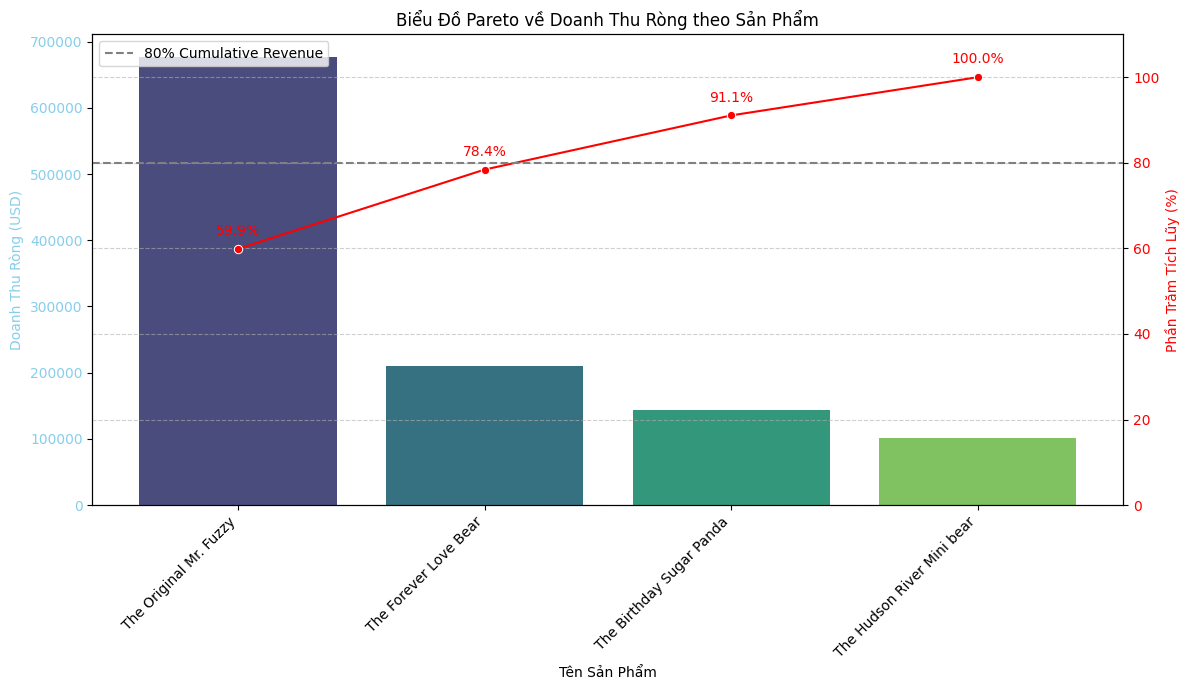

In [26]:
fig, ax1 = plt.subplots(figsize=(12, 7))

# Bar chart for Net Revenue
sns.barplot(x='product_name', y='net_revenue', data=revenue_by_product_sorted, ax=ax1, palette='viridis')
ax1.set_xlabel('Tên Sản Phẩm')
ax1.set_ylabel('Doanh Thu Ròng (USD)', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xticklabels(revenue_by_product_sorted['product_name'], rotation=45, ha='right')

# Create a second y-axis for Cumulative Percentage
ax2 = ax1.twinx()
sns.lineplot(x='product_name', y='cumulative_percentage', data=revenue_by_product_sorted, ax=ax2, color='red', marker='o', sort=False)
ax2.set_ylabel('Phần Trăm Tích Lũy (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110) # Set y-axis limit slightly above 100% for better visualization

# Add cumulative percentage labels on the line chart
for index, row in revenue_by_product_sorted.iterrows():
    ax2.annotate(f'{row["cumulative_percentage"]:,.1f}%',
                 (index, row['cumulative_percentage']),
                 textcoords="offset points", xytext=(0,10), ha='center', color='red')

# Add a line for the 80% mark (Pareto principle) for cumulative percentage
ax2.axhline(y=80, color='gray', linestyle='--', label='80% Cumulative Revenue')
ax2.legend(loc='upper left')

plt.title('Biểu Đồ Pareto về Doanh Thu Ròng theo Sản Phẩm')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Key Findings:**

**Key Products Based on the Pareto Principle:**

- The two products, “The Original Mr. Fuzzy” and “The Forever Love Bear,” together account for 78.41% of the store’s total net profit. This closely aligns with the Pareto principle, indicating that they are core products driving the majority of value.
- “The Original Mr. Fuzzy” is the clear top performer:
This product alone contributes 59.87% of total net profit, making it the most critical “cash-generating” item that should be prioritized above all others.
- “The Birthday Sugar Panda” and “The Hudson River Mini Bear” contribute less:
These products account for 12.67% and 8.93% of total net profit, respectively. While they still generate revenue, their impact is significantly lower compared to the leading products.

**Conclusion:**

- Based on the Pareto principle, to optimize warehouse space and focus resources, “The Original Mr. Fuzzy” and “The Forever Love Bear” are clearly the two key products that should be retained and even further invested in—whether through marketing, production, or supply chain optimization.
- For “The Birthday Sugar Panda” and “The Hudson River Mini Bear,” their performance should be evaluated more carefully. Although they are not as strong “cash generators” as the top two products, with the right strategies (e.g., bundling or promotional campaigns), they can still contribute value without taking up excessive space.

##### **Problem about refunds**

Although “The Original Mr. Fuzzy” and “The Forever Love Bear” are the two key products that should be retained based on the Pareto principle, their return rates need to be examined more carefully. This is essential to determine which product line should be prioritized and how to optimize overall net profit.

In [27]:
refund_analysis = merged_df.groupby('product_name').agg(
    total_net_revenue=('net_revenue', 'sum'),
    total_refund_cost=('refund_amount_usd', 'sum'),
    total_price_before_refund=('price_usd', 'sum')
).reset_index()

refund_analysis['refund_rate'] = (refund_analysis['total_refund_cost'] / refund_analysis['total_price_before_refund']) * 100

display(refund_analysis.sort_values(by='total_refund_cost', ascending=False))

,product_name,total_net_revenue,total_refund_cost,total_price_before_refund,refund_rate
3,The Original Mr. Fuzzy,677055.37,61837.63,1211057.74,5.106084
0,The Birthday Sugar Panda,143184.51,13842.99,229260.15,6.038114
1,The Forever Love Bear,209611.29,7738.71,347702.04,2.225673
2,The Hudson River Mini bear,100949.64,1919.36,150489.82,1.275409


**Key Findings:**

- The Original Mr. Fuzzy:
Has the highest net profit, but also the highest return cost ($61,837.63) and a relatively high return rate (5.11%). This suggests that although it is a core product, the causes behind its return rate should be carefully investigated.
- The Birthday Sugar Panda:
Has the highest return rate (6.04%) and a significant return cost. Although its net profit is not the highest, this return rate requires attention to avoid unnecessary losses.
- The Forever Love Bear:
Has the second-highest net profit and a relatively low return rate (2.23%), making it a highly efficient product.
- The Hudson River Mini Bear:
Has the lowest net profit and also the lowest return rate (1.28%).

### **Problem 2:**

**Problem Statement:**

After identifying which product generates the highest profit, the manager raises another challenging question:
“We are investing heavily in multiple advertising channels (Google, Facebook, Social, etc.), but which channels actually bring in high-quality customers?”

Your task is to identify the top 20% of traffic sources that generate 80% of total revenue, in order to help the Marketing team cut budget from underperforming channels and focus on the most effective ones.


### **Information of Data**

Based on the problem, the tables we will need to use are:

- website_sessions: Contains information about traffic sources (marketing channels) such as utm_source, utm_campaign, utm_medium, and website_session_id.
- orders: Includes order_id and website_session_id, allowing us to link sessions to orders, along with price_usd and cogs_usd for each order.
- order_items: Provides detailed information for each product within an order, including product_id, price_usd (selling price), and cogs_usd (cost of goods sold).
- order_item_refunds: Contains data on returned items and refund amounts (refund_amount_usd), which is essential for calculating net profit.
- products: Includes product_id and product_name, helping identify the corresponding product names.

In [30]:
order_item_refurnds.info()
order_items.info()
orders.info()
products.info()
website_sesions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1731 entries, 0 to 1730
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_item_refund_id  1731 non-null   int64  
 1   created_at            1731 non-null   object 
 2   order_item_id         1731 non-null   int64  
 3   order_id              1731 non-null   int64  
 4   refund_amount_usd     1731 non-null   float64
dtypes: float64(1), int64(3), object(1)
memory usage: 67.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40025 entries, 0 to 40024
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_item_id    40025 non-null  int64  
 1   created_at       40025 non-null  object 
 2   order_id         40025 non-null  int64  
 3   product_id       40025 non-null  int64  
 4   is_primary_item  40025 non-null  int64  
 5   price_usd        40025 non-null  float6

### **Handling Missing Value**

In [31]:
website_sesions.isnull().sum()

,0
website_session_id,0
created_at,0
user_id,1
is_repeat_session,1
utm_source,23148
utm_campaign,23148
utm_content,23148
device_type,1
http_referer,11067


Since the objective of the problem is to optimize revenue across marketing channels, we will process the utm_source column by replacing missing values with “Organic,” representing users who arrived naturally without any marketing channel involvement.

Additionally, we will remove only one record associated with a missing user_id along with its entire log. All other data will be retained as is.

In [33]:
website_sesions['utm_source'] = website_sesions['utm_source'].fillna('Organic')

# Kiểm tra lại các giá trị thiếu sau khi xử lý
website_sesions.isnull().sum()

,0
website_session_id,0
created_at,0
user_id,1
is_repeat_session,1
utm_source,0
utm_campaign,23148
utm_content,23148
device_type,1
http_referer,11067


In [34]:
website_sesions.dropna(subset=['user_id'], inplace=True)

# Kiểm tra lại các giá trị thiếu sau khi xử lý
website_sesions.isnull().sum()

,0
website_session_id,0
created_at,0
user_id,0
is_repeat_session,0
utm_source,0
utm_campaign,23147
utm_content,23147
device_type,0
http_referer,11066


##### **Analyze net profit by UTM Source**

In [35]:
# Merge order_items with order_item_refurnds to include refund information
order_items_with_refunds = pd.merge(
    order_items,
    order_item_refurnds[['order_item_id', 'refund_amount_usd']],
    on='order_item_id',
    how='left'
)

# Fill NaN refund amounts with 0 for items that were not refunded
order_items_with_refunds['refund_amount_usd'] = order_items_with_refunds['refund_amount_usd'].fillna(0)

# Calculate net revenue for each order item
order_items_with_refunds['net_revenue'] = (
    order_items_with_refunds['price_usd'] -
    order_items_with_refunds['cogs_usd'] -
    order_items_with_refunds['refund_amount_usd']
)

# Merge with orders to get website_session_id
orders_with_items_and_refunds = pd.merge(
    orders[['order_id', 'website_session_id']],
    order_items_with_refunds,
    on='order_id',
    how='inner'
)

# Merge with website_sesions to get utm_source
final_revenue_df = pd.merge(
    orders_with_items_and_refunds,
    website_sesions[['website_session_id', 'utm_source']],
    on='website_session_id',
    how='inner'
)

# Group by utm_source and sum the net revenue
net_profit_by_utm_source = final_revenue_df.groupby('utm_source')['net_revenue'].sum().reset_index()

# Sort by net revenue in descending order
net_profit_by_utm_source_sorted = net_profit_by_utm_source.sort_values(by='net_revenue', ascending=False).reset_index(drop=True)

display(net_profit_by_utm_source_sorted)


,utm_source,net_revenue
0,gsearch,209651.55
1,Organic,45403.21
2,bsearch,43528.95


##### **Create a Pareto table for UTM Sources**

In [36]:
# Calculate cumulative percentage
net_profit_by_utm_source_sorted['cumulative_percentage'] = (
    net_profit_by_utm_source_sorted['net_revenue'].cumsum() /
    net_profit_by_utm_source_sorted['net_revenue'].sum()
) * 100

display(net_profit_by_utm_source_sorted)


,utm_source,net_revenue,cumulative_percentage
0,gsearch,209651.55,70.215334
1,Organic,45403.21,85.421526
2,bsearch,43528.95,100.000000


##### **Pareto table visualization for UTM Sources**

/tmp/ipykernel_3706/1645579270.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='utm_source', y='net_revenue', data=net_profit_by_utm_source_sorted, ax=ax1, palette='viridis')
/tmp/ipykernel_3706/1645579270.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(net_profit_by_utm_source_sorted['utm_source'], rotation=45, ha='right')


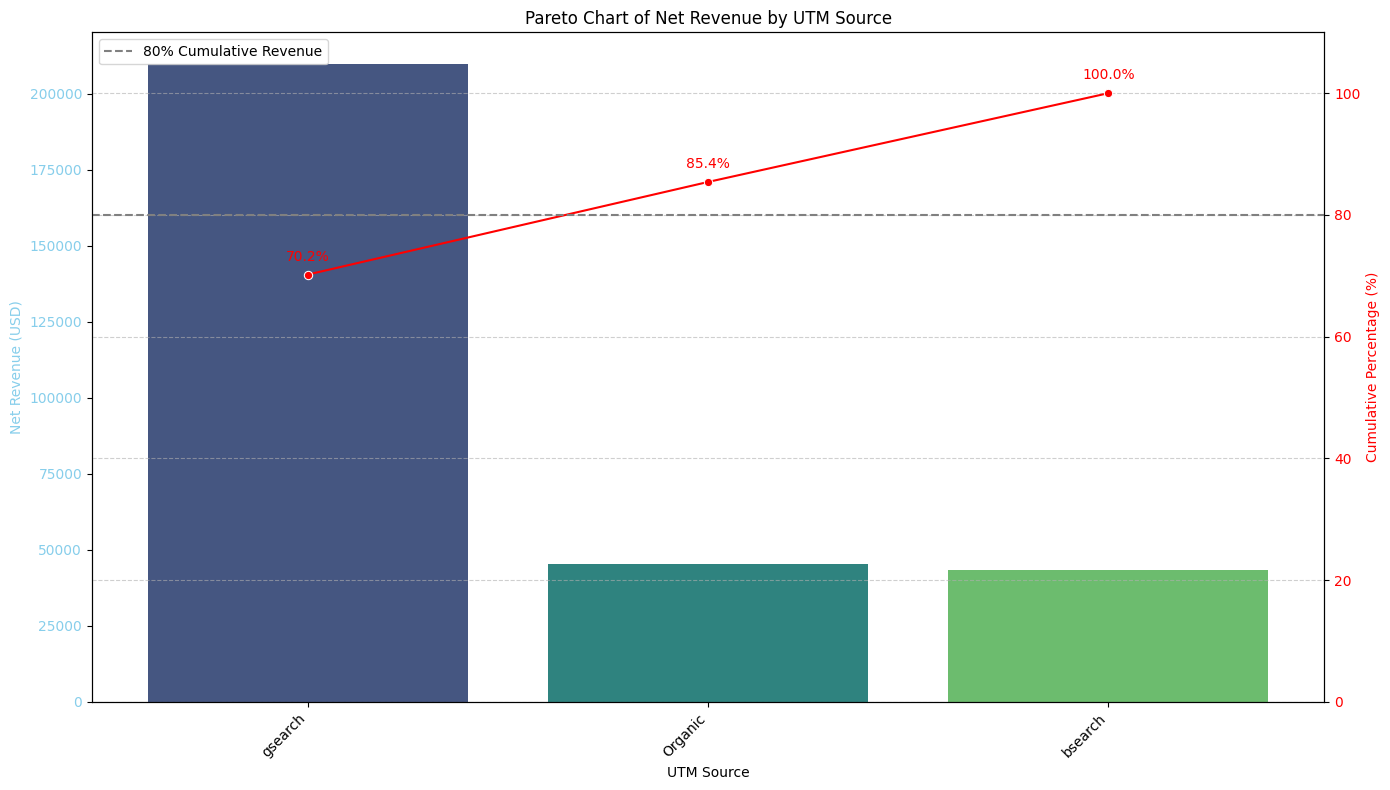

In [37]:
fig, ax1 = plt.subplots(figsize=(14, 8))

# Bar chart for Net Revenue
sns.barplot(x='utm_source', y='net_revenue', data=net_profit_by_utm_source_sorted, ax=ax1, palette='viridis')
ax1.set_xlabel('UTM Source')
ax1.set_ylabel('Net Revenue (USD)', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xticklabels(net_profit_by_utm_source_sorted['utm_source'], rotation=45, ha='right')

# Create a second y-axis for Cumulative Percentage
ax2 = ax1.twinx()
sns.lineplot(x='utm_source', y='cumulative_percentage', data=net_profit_by_utm_source_sorted, ax=ax2, color='red', marker='o', sort=False)
ax2.set_ylabel('Cumulative Percentage (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110) # Set y-axis limit slightly above 100% for better visualization

# Add cumulative percentage labels on the line chart
for index, row in net_profit_by_utm_source_sorted.iterrows():
    ax2.annotate(f'{row["cumulative_percentage"]:,.1f}%',
                 (index, row['cumulative_percentage']),
                 textcoords="offset points", xytext=(0,10), ha='center', color='red')

# Add a line for the 80% mark (Pareto principle) for cumulative percentage
ax2.axhline(y=80, color='gray', linestyle='--', label='80% Cumulative Revenue')
ax2.legend(loc='upper left')

plt.title('Pareto Chart of Net Revenue by UTM Source')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


##### **Key Findings:**
- gsearch: This channel alone accounts for 70.22% of the total net profit.
When combined with Organic traffic, these two sources bring the cumulative net profit to 85.42%.
- Therefore, gsearch and Organic are the critical 20% of your UTM sources (two out of three in this dataset) that are responsible for more than 80% of your net profit.

##### **Conclusion:**
- Prioritize Cutting from bsearch: This channel is the least efficient in terms of net revenue contribution. If a 50% reduction in marketing spend is required, this would be the first area to significantly scale back or even eliminate marketing efforts. By reducing spend here, you would shed the least profitable segment while preserving the bulk of your revenue.
- Maintain or Slightly Optimize Organic Traffic Investment: 'Organic' traffic is highly valuable as it doesn't incur direct advertising costs like 'gsearch' or 'bsearch'. Any marketing budget related to improving SEO, content creation, or user experience that drives organic traffic should ideally be preserved or even strategically invested in, as it contributes significantly to net profit (around 15% of total) with a high return.
- Carefully Protect gsearch: 'gsearch' is by far your most critical channel, responsible for over 70% of your net profit. Any cuts here should be a last resort and extremely strategic. Instead of blanket cuts, focus on optimizing campaigns, refining keywords, improving ad copy, and ensuring high conversion rates to maximize efficiency and maintain its strong performance. If cuts are absolutely necessary in gsearch, they should be targeted to remove only the lowest-performing campaigns or keywords.

In summary, to achieve a 50% marketing cost reduction with minimal impact on net profit, the strategy should be to significantly reduce or eliminate spend on bsearch, protect and optimize gsearch investments, and maintain or enhance efforts that drive Organic traffic. This approach leverages the Pareto principle to cut from the 'long tail' of less impactful channels first.